## Strategy evaluation

- compare alternate student loan repayment / investmet strategies
- each strategy is evaluated on the same stochastic salary and investment scenarios

In [1]:
from quant_slc_hedging.data_model import LoanModelInputs, SalaryModelInputs, InvestmentModelInputs, SalaryGrowthType, salary_growth_amounts
from quant_slc_hedging.salary import SalaryModel
from quant_slc_hedging.loan import LoanModel, LoanModelResult
from quant_slc_hedging.strategies.base_strategy import Strategy
from quant_slc_hedging.strategies.min_repayment import MinRepaymentStrategy
from quant_slc_hedging.strategies.fixed_pct_repayment import FixedPctRepaymentStrategy
from quant_slc_hedging.strategies.index_fund import IndexFundStrategy
from quant_slc_hedging.strategies.covered_call import CoveredCallStrategy
from quant_slc_hedging.simulation import SimulationHandler
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
from typing import List, Union
from dataclasses import dataclass

In [ ]:
n_paths = 10_000
years_remaining = 25
observations = years_remaining * 12
seed = 1234
starting_salary = 35_000
initial_loan = 45_000
initial_investment_balance = 5_000
repayment_threshold = 29_385 
salary_growth = SalaryGrowthType(growth_type="Medium")
annual_investment_pct = 0.07
annual_investment_vol = 0.16
annual_risk_free_rate = 0.03
payoff_loan_with_investments = True
output_path = "/Users/jakecowper/quant/quant-slc-hedging/src/quant_slc_hedging/outputs/"

In [3]:
salary_rng = np.random.default_rng(seed)
investment_rng = np.random.default_rng(seed + 1) 

salary_config=SalaryModelInputs(
    starting_salary=starting_salary,
    salary_growth_dist=salary_growth
    )
loan_config = LoanModelInputs(
    initial_loan_balance=initial_loan,
    remaining_loan_term_months=12*years_remaining,
    repayment_threshold=repayment_threshold
)
investment_config = InvestmentModelInputs(
    initial_investment_balance=initial_investment_balance,
    annual_expected_return=annual_investment_pct,
    annual_vol=annual_investment_vol,
    payoff_loan_with_investments=payoff_loan_with_investments
)


In [18]:
strategies = {
    "Minimum Repayment": MinRepaymentStrategy(),
    "5% Overpayment": FixedPctRepaymentStrategy(
        fixed_excess_pct=0.05,
        repayment_threshold=loan_config.repayment_threshold 
    ),
    "5% Invested Index Fund": IndexFundStrategy(
        investment_config=investment_config,
        investment_pct=0.05,
        repayment_pct=0.0,
        repayment_threshold=loan_config.repayment_threshold,
        rng_gen=investment_rng,
        n_paths=n_paths,
        n_obs=observations
    ),
    "5% Invested Index Fund 5% Overpayment": IndexFundStrategy(
        investment_config=investment_config,
        investment_pct=0.05,
        repayment_pct=0.05,
        repayment_threshold=loan_config.repayment_threshold,
        rng_gen=investment_rng,
        n_paths=n_paths,
        n_obs=observations
    ),
    "5% Invested Covered Call 5% Overpayment": CoveredCallStrategy(
        investment_config=investment_config,
        investment_pct=0.05,
        repayment_pct=0.05,
        target_moneyness=1.10,
        repayment_threshold=loan_config.repayment_threshold,
        rng_gen=investment_rng,
        n_paths=n_paths,
        n_obs=observations
    )
}

In [19]:
results = {}

for name, strategy in strategies.items():
    sim = SimulationHandler(salary_config=salary_config, loan_config=loan_config, investment_config=investment_config, strategy=strategy, n_paths=n_paths, observations=observations, salary_rng=salary_rng)
    results[name] = sim.run_simulation()

Sim finished
Sim finished
Sim finished
Sim finished
Sim finished


In [20]:
def calc_metrics(strategy_name, sim_res):
    lb = sim_res.loan_result.loan_balance
    interest = sim_res.loan_result.interest_accrued
    base = sim_res.loan_result.base_repayment
    additional = sim_res.loan_result.additional_repayment
    ib = sim_res.investment_balance
    terminal_wealth = ib[:, -1] - lb[:, -1]
    
    # Repayment and investment metrics
    expected_end_loan_balance = lb[:, -1].mean()
    med_end_loan_balance = np.median(lb[:, -1])
    expected_end_inv_balance = ib[:, -1].mean()
    med_end_inv_balance = np.median(ib[:, -1])
    expected_term_wealth = terminal_wealth.mean()
    median_term_wealth = np.median(terminal_wealth)
    loan_repaid = np.any(lb== 0, axis=1)
    probability_repaid = loan_repaid.mean()
    repaid = np.any(lb == 0, axis=1)
    repayment_month = np.full(n_paths, np.nan)
    repayment_month[repaid] = np.argmax(
        lb[repaid] == 0,
        axis=1,
    )
    repayment_year = repayment_month / 12
    total_base_payments = np.sum(base, axis=1).mean()
    total_add_payments = np.sum(additional, axis=1).mean()
    total_interest_payment = np.sum(interest, axis=1).mean()

    repayment_metrics = {
        "end_loan_balance": expected_end_loan_balance,
        "med_end_loan_balance": med_end_loan_balance,
        "end_inv_balance": expected_end_inv_balance,
        "med_end_inv_balance": med_end_inv_balance,
        "end_net_wealth": expected_term_wealth,
        "med_end_net_wealth": median_term_wealth,
        "probaility_repaid": probability_repaid,
        "probaility_repaid": probability_repaid,
    }
    return pd.DataFrame(repayment_metrics, index=[strategy_name])

metrics_df = pd.concat([calc_metrics(name, res) for name, res in results.items()])
print(metrics_df)
metrics_df.to_csv(f"{output_path}Comparisons.csv")

                                         end_loan_balance  \
Minimum Repayment                            37708.289550   
5% Overpayment                               14609.664665   
5% Invested Index Fund                       17614.745654   
5% Invested Index Fund 5% Overpayment         7140.319658   
5% Invested Covered Call 5% Overpayment       7771.139245   

                                         med_end_loan_balance  \
Minimum Repayment                                34288.352194   
5% Overpayment                                       0.000000   
5% Invested Index Fund                               0.000000   
5% Invested Index Fund 5% Overpayment                0.000000   
5% Invested Covered Call 5% Overpayment              0.000000   

                                         end_inv_balance  med_end_inv_balance  \
Minimum Repayment                            5000.000000          5000.000000   
5% Overpayment                               5000.000000          5000.000000   

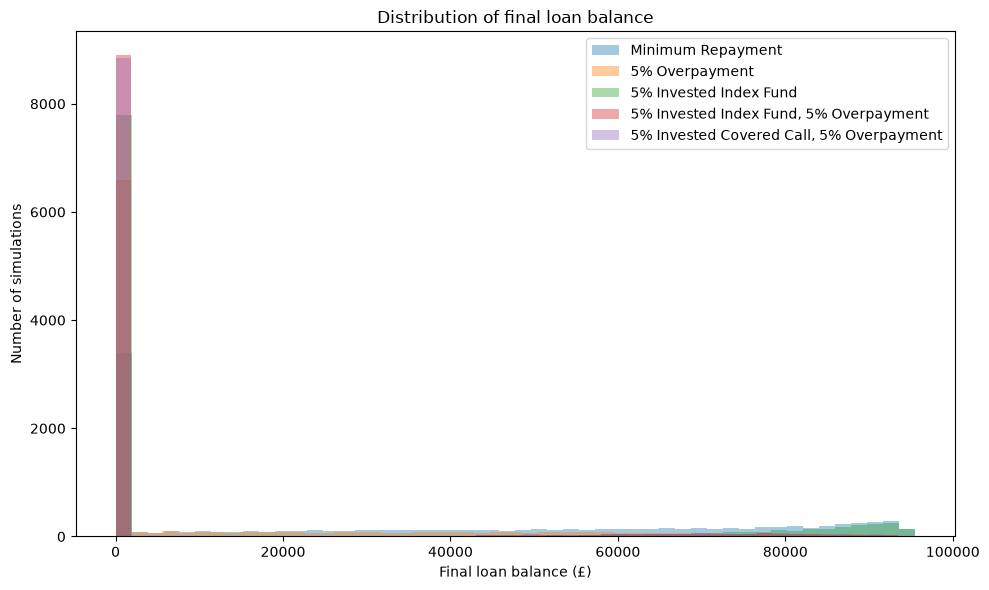

In [17]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

for strategy_name, result in results.items():
    final_loan = result.loan_result.loan_balance[:, -1]

    plt.hist(
        final_loan,
        bins=50,
        alpha=0.4,
        label=strategy_name,
    )

plt.xlabel("Final loan balance (£)")
plt.ylabel("Number of simulations")
plt.title("Distribution of final loan balance")
plt.legend()
plt.tight_layout()
plt.show()

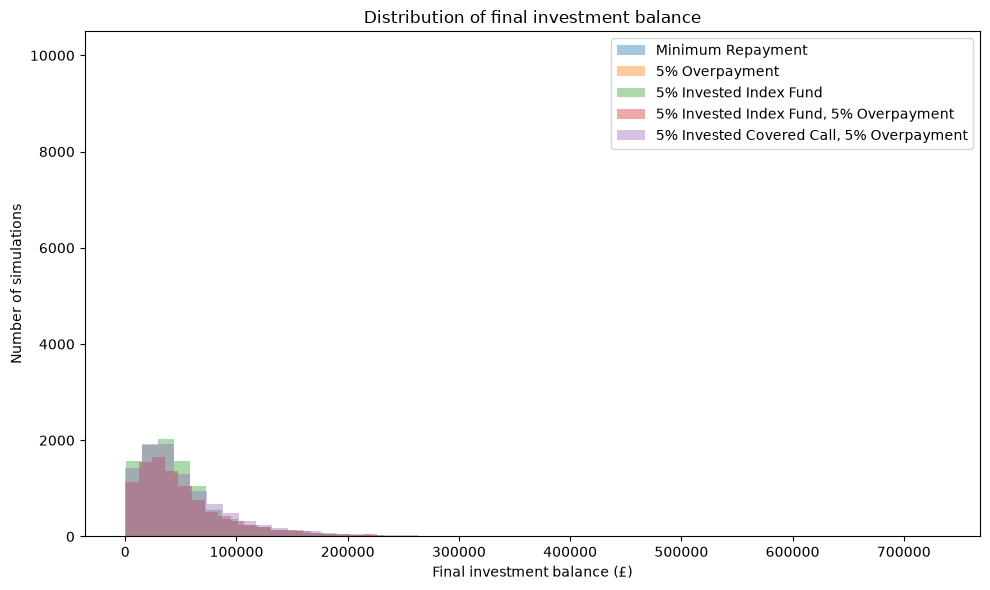

In [8]:
plt.figure(figsize=(10, 6))

for strategy_name, result in results.items():
    final_investment = result.investment_balance[:, -1]

    plt.hist(
        final_investment,
        bins=50,
        alpha=0.4,
        label=strategy_name,
    )

plt.xlabel("Final investment balance (£)")
plt.ylabel("Number of simulations")
plt.title("Distribution of final investment balance")
plt.legend()
plt.tight_layout()
plt.show()

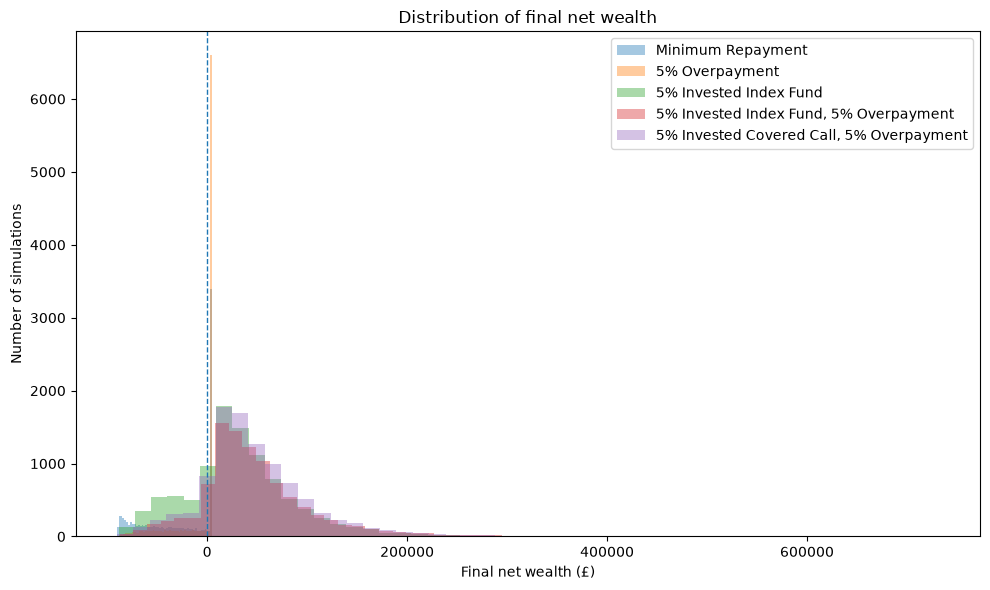

In [9]:
plt.figure(figsize=(10, 6))

for strategy_name, result in results.items():
    final_loan = result.loan_result.loan_balance[:, -1]
    final_investment = result.investment_balance[:, -1]

    final_net_wealth = final_investment - final_loan

    plt.hist(
        final_net_wealth,
        bins=50,
        alpha=0.4,
        label=strategy_name,
    )

plt.axvline(
    0,
    linestyle="--",
    linewidth=1,
)

plt.xlabel("Final net wealth (£)")
plt.ylabel("Number of simulations")
plt.title("Distribution of final net wealth")
plt.legend()
plt.tight_layout()
plt.show()

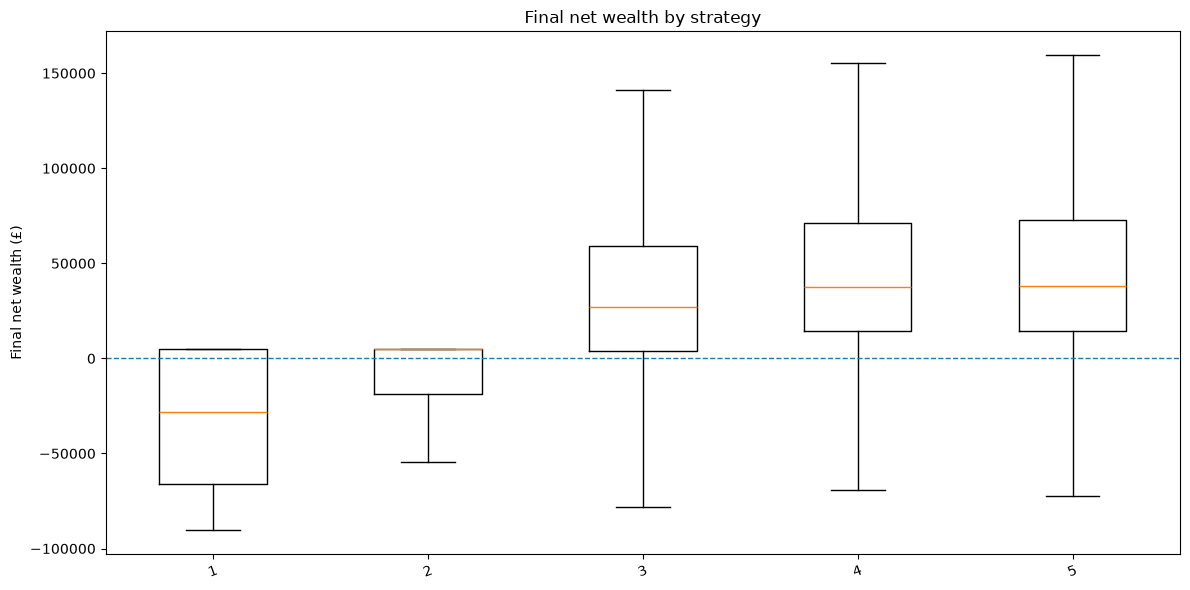

In [10]:
net_wealth_data = []

strategy_names = []

for strategy_name, result in results.items():
    final_loan = result.loan_result.loan_balance[:, -1]
    final_investment = result.investment_balance[:, -1]

    net_wealth = final_investment - final_loan

    net_wealth_data.append(net_wealth)
    strategy_names.append(strategy_name)

plt.figure(figsize=(12, 6))

plt.boxplot(
    net_wealth_data,
    label=strategy_names,
    showfliers=False,
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1,
)

plt.ylabel("Final net wealth (£)")
plt.title("Final net wealth by strategy")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

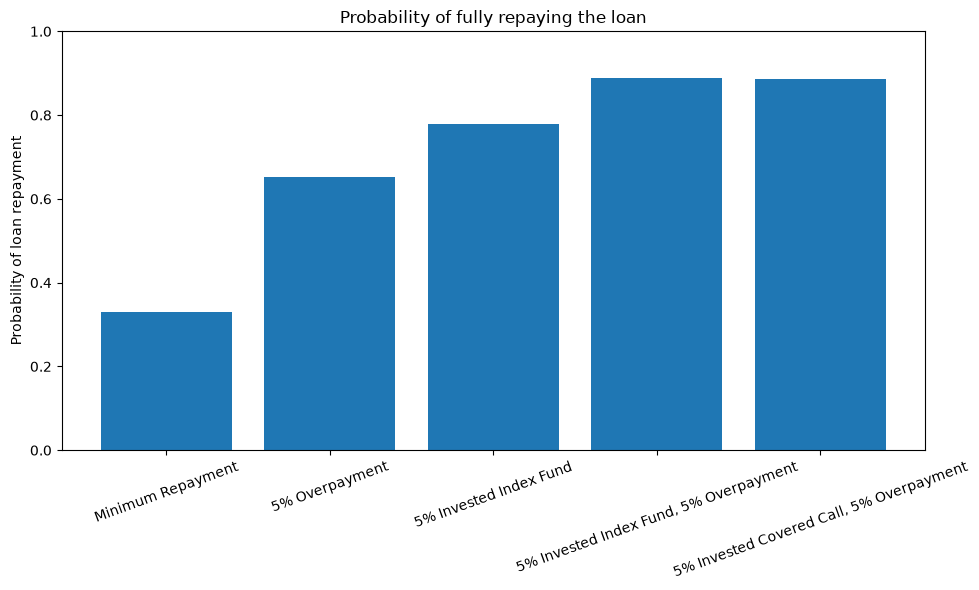

In [11]:
repayment_probability = {}

for strategy_name, result in results.items():
    final_loan = result.loan_result.loan_balance[:, -1]

    repayment_probability[strategy_name] = np.mean(
        final_loan <= 1e-8
    )

repayment_probability

plt.figure(figsize=(10, 6))

plt.bar(
    repayment_probability.keys(),
    repayment_probability.values(),
)

plt.ylabel("Probability of loan repayment")
plt.title("Probability of fully repaying the loan")
plt.xticks(rotation=20)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()